## 8.7 밀도행렬을 이용한 양자 경제물리학

In [1]:
# Qiskit 라이브러리 임포트
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix, partial_trace, Operator, random_unitary, Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 경제 시스템을 모델링하는 더 복잡한 양자회로 정의
qc = QuantumCircuit(3)
qc.h(0)  # 큐비트 0에 하다마드 게이트
qc.cx(0, 1)  # 큐비트 0,1 얽힘
qc.cx(1, 2)  # 큐비트 1,2 추가 얽힘
qc.ry(0.5, 2)  # 큐비트 2에 회전 추가

In [3]:
# 시스템에 무작위 유니타리 변환 적용
random_op = random_unitary(8)  # 3큐비트이므로 2^3 = 8
qc.append(random_op, [0, 1, 2])

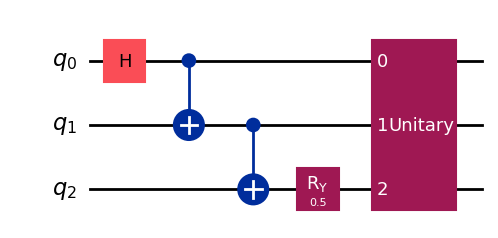

In [4]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [5]:
# AerSimulator로 양자 상태 시뮬레이션
simulator = AerSimulator()
result = simulator.run(qc).result()

In [6]:
# 전체 시스템의 상태벡터와 밀도행렬 획득
state = Statevector.from_instruction(qc)
density_matrix = DensityMatrix(state)

In [7]:
# 밀도행렬 출력
print("얽힌 경제 시스템의 밀도행렬:\n", density_matrix)

얽힌 경제 시스템의 밀도행렬:
 DensityMatrix([[ 0.03922203+9.86008652e-20j,  0.02986   +7.74071457e-02j,
                -0.00268903-2.12839278e-02j, -0.09307166+1.22616628e-02j,
                -0.07309923+1.24394762e-02j,  0.0287485 -1.34227866e-02j,
                -0.09004949+3.89059850e-02j,  0.0494186 -5.43837038e-02j],
               [ 0.02986   -7.74071457e-02j,  0.1755005 +3.83224147e-19j,
                -0.04405235-1.08966358e-02j, -0.04665693+1.93017664e-01j,
                -0.03110086+1.53736203e-01j, -0.00460429-6.69558310e-02j,
                 0.00822812+2.07337743e-01j, -0.06970695-1.38933401e-01j],
               [-0.00268903+2.12839278e-02j, -0.04405235+1.08966358e-02j,
                 0.01173413+2.75119387e-19j, -0.00027291-5.13462045e-02j,
                -0.00173869-4.05203133e-02j,  0.00531294+1.65206951e-02j,
                -0.01493871-5.15329323e-02j,  0.02612335+3.05456175e-02j],
               [-0.09307166-1.22616628e-02j, -0.04665693-1.93017664e-01j,
                -

In [8]:
# 부분 대각합으로 각 큐비트의 축소 밀도행렬 획득
reduced_density_matrix_0 = partial_trace(density_matrix, [1, 2])
reduced_density_matrix_1 = partial_trace(density_matrix, [0, 2])
reduced_density_matrix_2 = partial_trace(density_matrix, [0, 1])

print("\n축소 밀도행렬 (큐비트 0):\n", reduced_density_matrix_0)
print("\n축소 밀도행렬 (큐비트 1):\n", reduced_density_matrix_1)
print("\n축소 밀도행렬 (큐비트 2):\n", reduced_density_matrix_2)


축소 밀도행렬 (큐비트 0):
 DensityMatrix([[ 0.43647486-2.01020105e-18j, -0.19565462+1.17798290e-01j],
               [-0.19565462-1.17798290e-01j,  0.56352514+3.90464602e-18j]],
              dims=(2,))

축소 밀도행렬 (큐비트 1):
 DensityMatrix([[0.3805703+1.94590857e-18j, 0.1856549+1.04833993e-01j],
               [0.1856549-1.04833993e-01j, 0.6194297-5.14636005e-20j]],
              dims=(2,))

축소 밀도행렬 (큐비트 2):
 DensityMatrix([[ 0.4511437+2.73796135e-18j, -0.2269113+7.55083138e-03j],
               [-0.2269113-7.55083138e-03j,  0.5488563-8.43516381e-19j]],
              dims=(2,))


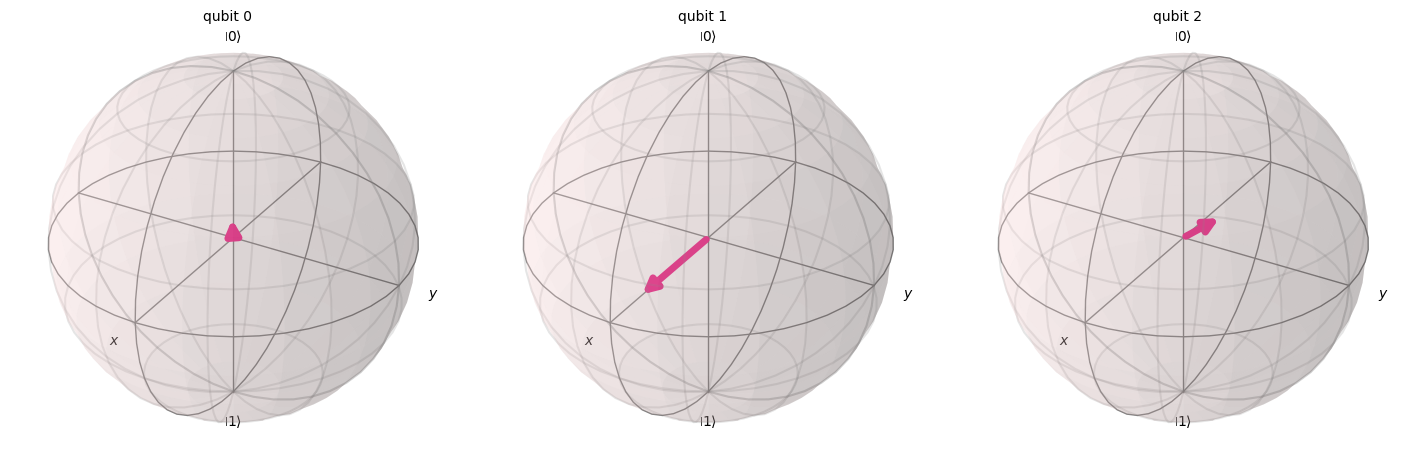

In [9]:
# 밀도행렬의 블로흐 구 시각화
plot_bloch_multivector(state)
plt.show()

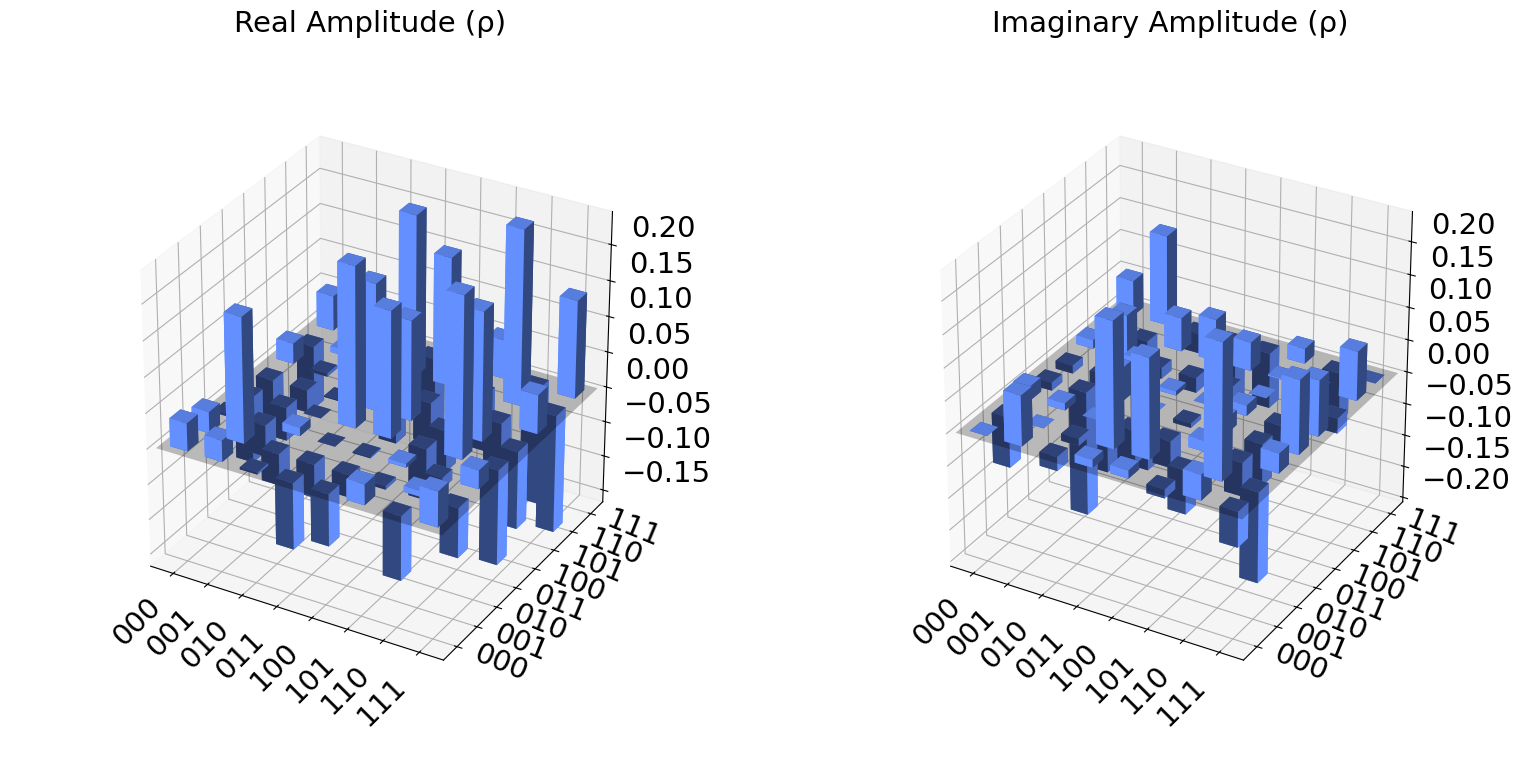

In [10]:
# state city 표현으로 상태 시각화
plot_state_city(density_matrix)
plt.show()

In [11]:
# 히스토그램 시각화를 위해 큐비트 측정
qc.measure_all()

In [12]:
# 시뮬레이션 실행 후 측정 결과 획득
measurement_result = simulator.run(qc).result().get_counts()

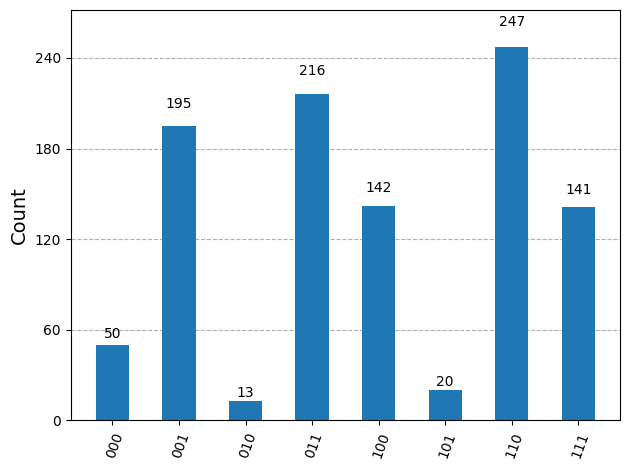

In [13]:
# 측정 결과를 히스토그램으로 시각화
plot_histogram(measurement_result)
plt.show()